## Loading Libraries

In [1]:
from pandas import read_csv
import time
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif

In [3]:
from google.colab import files
import pandas as pd
import io

# 1. Trigger the upload prompt
uploaded = files.upload()

# 2. Read the file into a Pandas DataFrame (replace 'your_file.csv' with your actual filename)
df = pd.read_csv(io.BytesIO(uploaded['Salaries.csv']))
df.head()


Saving Salaries.csv to Salaries.csv


,rank,discipline,phd,service,sex,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800


## Preparing the dataset

The `Salaries.csv` dataset has columns `rank, discipline, phd, service, sex, salary`. We will predict **sex** from the other columns. `rank` and `discipline` are text categories, so we label-encode them into numbers so they can be used as model features.

In [4]:
from sklearn.preprocessing import LabelEncoder

dataset = pd.read_csv("Salaries.csv")

# Encode categorical feature columns (rank, discipline) as numbers
le_rank = LabelEncoder()
le_discipline = LabelEncoder()
dataset['rank_enc'] = le_rank.fit_transform(dataset['rank'])
dataset['discipline_enc'] = le_discipline.fit_transform(dataset['discipline'])

dataset.head()

,rank,discipline,phd,service,sex,salary,rank_enc,discipline_enc
0,Prof,B,56,49,Male,186960,2,1
1,Prof,A,12,6,Male,93000,2,0
2,Prof,A,23,20,Male,110515,2,0
3,Prof,A,40,31,Male,131205,2,0
4,Prof,B,20,18,Male,104800,2,1


## Splitting datasets into train and test

In [5]:
# Build feature matrix X (rank_enc, discipline_enc, phd, service, salary) and target y (sex)
X = dataset[['rank_enc', 'discipline_enc', 'phd', 'service', 'salary']].values
y = dataset['sex'].values

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

## 1) Naive Bayes Algorithm

In [6]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
import pandas as pd

# prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# create model
model_NB = GaussianNB()

# evaluate model
scores1 = cross_val_score(model_NB, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_NB, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_NB, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_NB, X_train, y_train, scoring='f1_macro', cv=cv)

# report performance
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)' % (scores4.mean(), scores4.std()))

Accuracy: 0.595 (0.135)
Precision: 0.681 (0.098)
Recall: 0.695 (0.097)
F1-score: 0.586 (0.135)


## 2) k-Nearest-Neighbors Algorithm (kNN)

In [8]:
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.neighbors import KNeighborsClassifier

# Create model
model_KNN = KNeighborsClassifier(n_neighbors=3)

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Evaluate model using cross-validation
scores1 = cross_val_score(model_KNN, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_KNN, X_train, y_train, scoring='precision_weighted', cv=cv)
scores3 = cross_val_score(model_KNN, X_train, y_train, scoring='recall_weighted', cv=cv)
scores4 = cross_val_score(model_KNN, X_train, y_train, scoring='f1_weighted', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)' % (scores4.mean(), scores4.std()))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.695 (0.175)
Precision: 0.750 (0.158)
Recall: 0.695 (0.175)
F1-score: 0.695 (0.162)


## 3) Decision Trees Algorithms

In [9]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from numpy import mean, std

# Create model
model_DT = DecisionTreeClassifier()

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Evaluate model
scores1 = cross_val_score(model_DT, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_DT, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_DT, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_DT, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.417 (0.157)
Precision: 0.451 (0.222)
Recall: 0.452 (0.284)
F1-score: 0.438 (0.176)


## 4) Support Vector Machine Algorithm (SVM)

In [10]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
import pandas as pd
from numpy import mean, std

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Create model
model_SVM = SVC()

# Evaluate model
scores1 = cross_val_score(model_SVM, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_SVM, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_SVM, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_SVM, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.452 (0.179)
Precision: 0.486 (0.256)
Recall: 0.590 (0.120)
F1-score: 0.422 (0.181)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 5) Random Forest

In [11]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from numpy import mean, std

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)

# Create model
model_RF = RandomForestClassifier()

# Evaluate model
scores1 = cross_val_score(model_RF, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_RF, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_RF, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_RF, X_train, y_train, scoring='f1_macro', cv=cv)

# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.562 (0.214)
Precision: 0.607 (0.237)
Recall: 0.574 (0.227)
F1-score: 0.555 (0.236)


## Compare Algorithms

LR: 0.547619 (0.179126)
LDA: 0.664286 (0.067721)
KNN: 0.645238 (0.198478)
CART: 0.454762 (0.150000)
NB: 0.652381 (0.129187)
SVM: 0.480952 (0.078824)


/tmp/ipykernel_1166/339937392.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


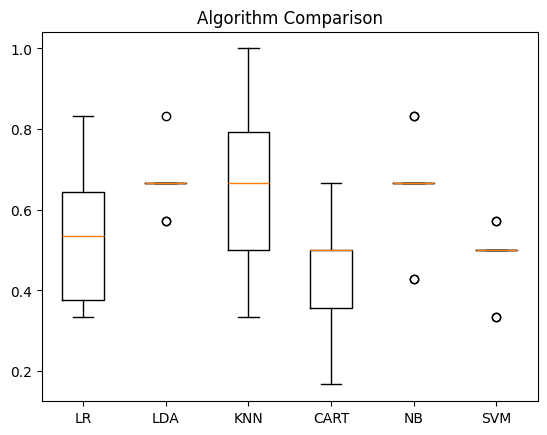

In [12]:
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

#Select Best Model
#=================================
# Compare Algorithms
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison')
plt.show()